# Стих и звук: метр, рифма и фоностатистика поэзии

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SergeyShk/ruTS/blob/master/examples/05_poetry.ipynb)

[`PoetryCorpus`](https://sergeyshk.github.io/ruTS/datasets/poetrycorpus/) - 16 694 стихотворения 195 авторов от Тредиаковского до 1990-х, у большинства есть год написания. На нём разбираются [стиховедческие статистики](https://sergeyshk.github.io/ruTS/stats/verse_stats/) [ruTS](https://github.com/SergeyShk/ruTS): ударения по [словарю Козиева](https://sergeyshk.github.io/ruTS/datasets/stressdict/), метр и число стоп, профиль ударности, схемы рифмовки и окончания строк, а затем [фоностатистики](https://sergeyshk.github.io/ruTS/stats/phon_stats/) - ударные гласные, аллитерация и звуковой облик текста у разных авторов.

Главный вопрос ноутбука - воспроизводит ли автоматический разбор то, что стиховедение знает по ручным подсчётам: смену господствующих размеров от XVIII века к XX, профиль ударности четырёхстопного ямба, рост трёхсложников и дольников, сдвиг от женских окончаний к дактилическим.

## Установка и данные

В Colab ячейка ставит библиотеку; модель spaCy не нужна. Корпус (26 МБ) и словарь ударений (архив 10 МБ, файл 77 МБ) загружаются один раз в `ruts_data`.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("ruts") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ruts"], check=True)

In [2]:
import pandas as pd

from ruts.datasets import PoetryCorpus, StressDict

pc = PoetryCorpus()
pc.download()
stress_dict = StressDict()
stress_dict.download()

corpus = pd.DataFrame(pc.get_records())
corpus["n_words"] = corpus["text"].str.count(r"[а-яёА-ЯЁ]+")
print(
    len(corpus),
    "стихотворений,",
    corpus["author"].nunique(),
    "авторов,",
    corpus["n_words"].sum(),
    "слов",
)
corpus["year_from"].describe().round().to_frame("год").T

16694 стихотворений, 195 авторов, 2149921 слов


,count,mean,std,min,25%,50%,75%,max
год,12857.0,1901.0,53.0,1725.0,1856.0,1913.0,1942.0,1996.0


## Один текст: ударения, метр, рифма

`VerseStats` делит текст на строки и строфы, ставит ударения по словарю и подбирает метр: у каждого из пяти силлабо-тонических метров свои сильные позиции (икты), выбирается тот, при котором меньше всего ударений многосложных слов попадает на слабые слоги. Метр, в свою очередь, снимает неоднозначность ударений: односложные слова ударны только на икте, служебные безударны вне икта, подвижные формы (воды́ - во́ды) и слова вне словаря подгоняются под икты. Рифма ищется по фонетическому ключу окончания строки - ударной гласной, согласным после неё и числу заударных слогов.

Онегинская строфа - хорошая проверка сразу всему: четырёхстопный ямб с чередованием женских и мужских окончаний и схема AbAbCCddEffEgg, где после перекрёстного четверостишия идут парное и опоясывающее.

In [3]:
from ruts import VerseStats

onegin = """Мой дядя самых честных правил,
Когда не в шутку занемог,
Он уважать себя заставил
И лучше выдумать не мог.
Его пример другим наука;
Но, боже мой, какая скука
С больным сидеть и день и ночь,
Не отходя ни шагу прочь!
Какое низкое коварство
Полуживого забавлять,
Ему подушки поправлять,
Печально подносить лекарство,
Вздыхать и думать про себя:
Когда же черт возьмет тебя!"""

vs = VerseStats(onegin, stress_dict)
print(vs.accentuate())
print()
vs.print_stats()

Мой дя́дя са́мых че́стных пра́вил,
Когда́ не в шу́тку занемо́г,
Он уважа́ть себя́ заста́вил
И лу́чше вы́думать не мо́г.
Его́ приме́р други́м нау́ка;
Но, бо́же мо́й, кака́я ску́ка
С больны́м сиде́ть и де́нь и но́чь,
Не отходя́ ни ша́гу про́чь!
Како́е ни́зкое кова́рство
Полуживо́го забавля́ть,
Ему́ поду́шки поправля́ть,
Печа́льно подноси́ть лека́рство,
Вздыха́ть и ду́мать про себя́:
Когда́ же че́рт возьме́т тебя́!

               Статистика               |  Значение  
----------------------------------------------------
Количество строк                        |     14     
Количество строф                        |     1      
Метр                                    |    ямб     
Число стоп                              |     4      
Доля отклонений от метра                |    0.00    
Доля пропущенных ударений на иктах      |    0.18    
Доля рифмованных строк                  |    1.00    
Доля мужских окончаний                  |    0.57    
Доля женских окончаний                  |   

In [4]:
pd.DataFrame(
    {
        "строка": vs.lines,
        "схема": vs.patterns,
        "ударные слоги": vs.stresses,
        "рифма": list(vs.rhyme_schemes[0]),
    }
)

,строка,схема,ударные слоги,рифма
0,"Мой дядя самых честных правил,",cCcCcCcCc,"(1, 3, 5, 7)",A
1,"Когда не в шутку занемог,",cCcCcccC,"(1, 3, 7)",B
2,Он уважать себя заставил,cccCcCcCc,"(3, 5, 7)",A
3,И лучше выдумать не мог.,cCcCcccC,"(1, 3, 7)",B
4,Его пример другим наука;,cCcCcCcCc,"(1, 3, 5, 7)",C
5,"Но, боже мой, какая скука",cCcCcCcCc,"(1, 3, 5, 7)",C
6,"С больным сидеть и день и ночь,",cCcCcCcC,"(1, 3, 5, 7)",D
7,Не отходя ни шагу прочь!,cccCcCcC,"(3, 5, 7)",D
8,Какое низкое коварство,cCcCcccCc,"(1, 3, 7)",E
9,"Полуживого забавлять,",cccCcccC,"(3, 7)",F


Схема рифмовки `ABABCCDDEFFEGG` совпадает с канонической, восемь мужских и шесть женских окончаний - тоже. Профиль ударности строфы - доля строк с ударением на каждом из четырёх иктов - уже здесь показывает то, что станет главным сюжетом ниже: третий икт слабее остальных.

In [5]:
print("Профиль ударности:", [round(share, 2) for share in vs.stress_profile])
print("Пиррихии:", round(vs.p_pyrrhics, 2), " Ударные гласные:", vs.c_stressed_vowels)

Профиль ударности: [0.79, 0.93, 0.57, 1.0]
Пиррихии: 0.18  Ударные гласные: {'а': 12, 'о': 9, 'я': 7, 'у': 7, 'е': 6, 'и': 3, 'ы': 2}


## Разбор корпуса

Один проход по 16 694 стихотворениям занимает около двадцати секунд. Из результатов берутся метр, число стоп, доля отклонений от метра, профиль ударности, схемы рифмовки, доли окончаний и распределение ударных гласных. Стихотворения без года (3 837) остаются в таблице, но выпадают из сравнений по эпохам.

In [6]:
rows = []
for text in corpus["text"]:
    vs = VerseStats(text, stress_dict)
    rows.append(
        {
            "meter": vs.meter,
            "n_feet": vs.n_feet,
            "c_feet": vs.c_feet,
            "n_lines": vs.n_lines,
            "p_deviations": vs.p_deviations,
            "p_pyrrhics": vs.p_pyrrhics,
            "profile": vs.stress_profile,
            "schemes": vs.rhyme_schemes,
            "p_rhymed": vs.p_rhymed,
            "p_masculine": vs.p_masculine,
            "p_feminine": vs.p_feminine,
            "p_dactylic": vs.p_dactylic,
            "vowels": vs.c_stressed_vowels,
        }
    )
verse = pd.concat([corpus.drop(columns=["text"]), pd.DataFrame(rows)], axis=1)
verse["meter"] = verse["meter"].fillna("нет")

ERAS = [1700, 1800, 1840, 1880, 1910, 1930, 1960, 2000]
ERA_LABELS = [
    "XVIII век",
    "1800-1839",
    "1840-1879",
    "1880-1909",
    "1910-1929",
    "1930-1959",
    "1960-1996",
]
METERS = ["ямб", "хорей", "дактиль", "амфибрахий", "анапест", "нет"]
verse["era"] = pd.cut(verse["year_from"], bins=ERAS, labels=ERA_LABELS, right=False)
verse["meter"].value_counts(normalize=True).round(3).to_frame("доля").T

meter,ямб,хорей,нет,анапест,амфибрахий,дактиль
доля,0.502,0.173,0.154,0.08,0.064,0.027


## Метры по эпохам

Половина корпуса - ямб, шестая часть - хорей, трёхсложники вместе - 17%, и у 15% стихотворений метр не подобран: после подгонки больше десятой части ударений остаётся на слабых позициях. По эпохам картина складывается в известную из стиховедения:

*   в XVIII веке ямб господствует, но пятая часть текстов без метра - это силлабика Тредиаковского (у него метр не определён в 60% стихотворений) и кантаты с переменным размером;
*   1800-1839 - вершина ямба (73%), трёхсложники единичны;
*   с 1840-х трёхсложники выходят на 20% - Некрасов, Фет, Майков; дактиль у Некрасова занимает столько же, сколько анапест;
*   1910-1929 - второй пик текстов без метра (22%): дольники и акцентный стих Ахматовой, Цветаевой, Маяковского, Хлебникова.

meter,ямб,хорей,дактиль,амфибрахий,анапест,нет
era,,,,,,
XVIII век,59.3,15.1,0.8,1.1,1.6,22.1
1800-1839,73.0,14.5,0.4,4.2,1.1,6.9
1840-1879,55.1,16.4,5.6,8.1,6.8,8.0
1880-1909,48.0,18.1,5.9,6.5,11.6,9.9
1910-1929,42.8,18.1,2.7,6.0,8.4,22.1
1930-1959,45.9,18.7,1.4,7.6,10.0,16.5
1960-1996,47.3,13.9,1.5,5.9,10.6,20.8


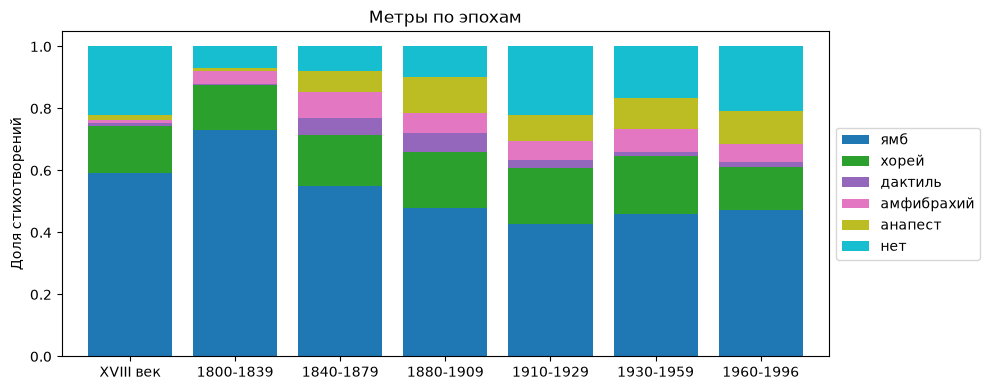

In [7]:
import matplotlib.pyplot as plt

dated = verse.dropna(subset=["era"])
by_era = pd.crosstab(dated["era"], dated["meter"], normalize="index")[METERS]
ax = by_era.plot.bar(stacked=True, figsize=(10, 4), width=0.8, colormap="tab10")
ax.set_xlabel("")
ax.set_ylabel("Доля стихотворений")
ax.set_title("Метры по эпохам")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
(by_era * 100).round(1)

Число стоп у ямба меняется так же предсказуемо: в XVIII веке почти половина ямбических стихотворений - шестистопник, александрийский стих од и трагедий; в первой трети XIX века шестистопник уступает четырёхстопному, а во второй половине XX века больше всего пятистопного ямба. У Крылова «вольный ямб» басен виден по распределению строк: от двух до шести стоп в одном тексте.

,title,meter,n_feet,c_feet
180,Пастух,ямб,6.0,"{2: 1, 3: 2, 4: 5, 5: 6, 6: 6}"
341,Эпиграмма рецензенту поэмы «Руслан и Людмила»,ямб,6.0,"{4: 1, 6: 3}"
461,Синица,ямб,6.0,"{2: 1, 3: 4, 4: 8, 5: 4, 6: 11}"
755,Обезьяны,ямб,6.0,"{2: 5, 3: 4, 4: 11, 5: 9, 6: 13}"
912,Лисица и виноград,ямб,6.0,"{2: 2, 3: 1, 4: 4, 5: 2, 6: 4}"


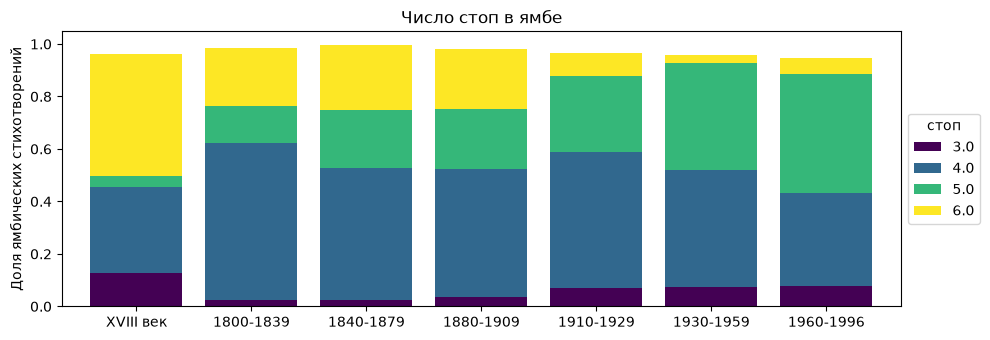

In [8]:
iamb = dated[dated["meter"] == "ямб"]
feet_by_era = pd.crosstab(iamb["era"], iamb["n_feet"], normalize="index")
feet_by_era = feet_by_era[[feet for feet in feet_by_era.columns if feet in (3, 4, 5, 6)]]
ax = feet_by_era.plot.bar(stacked=True, figsize=(10, 3.5), width=0.8, colormap="viridis")
ax.set_xlabel("")
ax.set_ylabel("Доля ямбических стихотворений")
ax.set_title("Число стоп в ямбе")
ax.legend(title="стоп", loc="center left", bbox_to_anchor=(1, 0.5))
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
krylov = verse[verse["author"] == "Иван Крылов"]
krylov[["title", "meter", "n_feet", "c_feet"]].head(5)

## Профиль ударности четырёхстопного ямба

Профиль ударности - доля строк с ударением на каждом икте - главный инструмент русского стиховедения от Андрея Белого до Тарановского и Гаспарова. Для четырёхстопного ямба известны два типа профиля. У Ломоносова и одической традиции XVIII века он «рамочный»: первый икт сильнее второго, третий пропускается реже. С конца XVIII века устанавливается «альтернирующий» профиль: второй икт сильнее первого, третий - самый слабый, последний ударен всегда (закон регрессивной акцентной диссимиляции Тарановского). Для Пушкина ручные подсчёты Тарановского дают примерно 84, 90, 44 и 100% по иктам.

Автоматический профиль повторяет обе картины: у Ломоносова первый икт ударен в 94% строк, третий - в 64%, а у Пушкина профиль совпадает с ручным в пределах полутора процентов по каждому икту.

,I,II,III,IV,стихотворений
XVIII век,86.7,80.0,62.4,98.8,58
1800-1839,83.1,89.5,48.3,98.6,724
1910-1929,80.0,83.5,52.1,96.8,484
Ломоносов,93.5,81.4,63.5,98.9,11
Пушкин,83.6,91.4,43.6,99.2,167
Блок,84.6,88.0,53.6,97.8,96


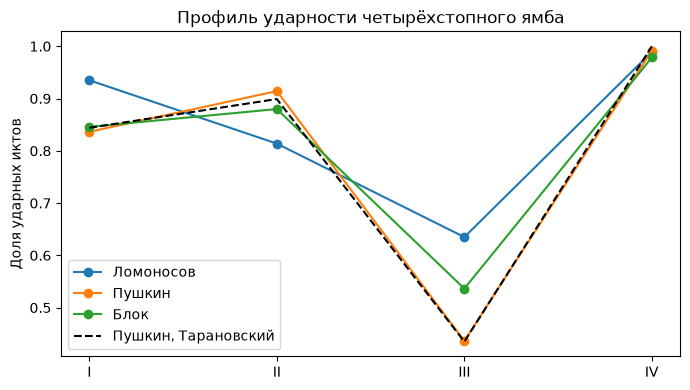

In [9]:
import numpy as np


def mean_profile(rows: pd.DataFrame, n_feet: int = 4) -> np.ndarray:
    """Средний профиль ударности по стихотворениям с заданным числом иктов"""
    profiles = [profile for profile in rows["profile"] if len(profile) == n_feet]
    return np.mean(profiles, axis=0)


iamb4 = verse[(verse["meter"] == "ямб") & (verse["n_feet"] == 4)]
groups = {
    "XVIII век": iamb4[iamb4["era"] == "XVIII век"],
    "1800-1839": iamb4[iamb4["era"] == "1800-1839"],
    "1910-1929": iamb4[iamb4["era"] == "1910-1929"],
    "Ломоносов": iamb4[iamb4["author"] == "Михаил Ломоносов"],
    "Пушкин": iamb4[iamb4["author"] == "Александр Пушкин"],
    "Блок": iamb4[iamb4["author"] == "Александр Блок"],
}
profiles = pd.DataFrame(
    {name: mean_profile(rows) for name, rows in groups.items()}, index=["I", "II", "III", "IV"]
).T
profiles["стихотворений"] = [
    sum(len(profile) == 4 for profile in rows["profile"]) for rows in groups.values()
]
fig, ax = plt.subplots(figsize=(7, 4))
for name in ("Ломоносов", "Пушкин", "Блок"):
    ax.plot(
        ["I", "II", "III", "IV"],
        profiles.loc[name, ["I", "II", "III", "IV"]],
        marker="o",
        label=name,
    )
ax.plot(["I", "II", "III", "IV"], [0.844, 0.899, 0.435, 1.0], "k--", label="Пушкин, Тарановский")
ax.set_ylabel("Доля ударных иктов")
ax.set_title("Профиль ударности четырёхстопного ямба")
ax.legend()
plt.tight_layout()
(profiles.iloc[:, :4] * 100).round(1).join(profiles["стихотворений"])

## Метры по авторам

Доли метров у двадцати четырёх авторов с наибольшим числом стихотворений плюс несколько показательных имён. Тютчев и Баратынский - ямбисты на 83%, Некрасов делит стих между ямбом и трёхсложниками, Есенин пишет хореем и анапестом чаще, чем ямбом, у детских авторов - Барто и Чуковского - господствует хорей. Крайние случаи - Маяковский (акцентный стих, метр не подобран у 70% текстов) и Тредиаковский (силлабика).

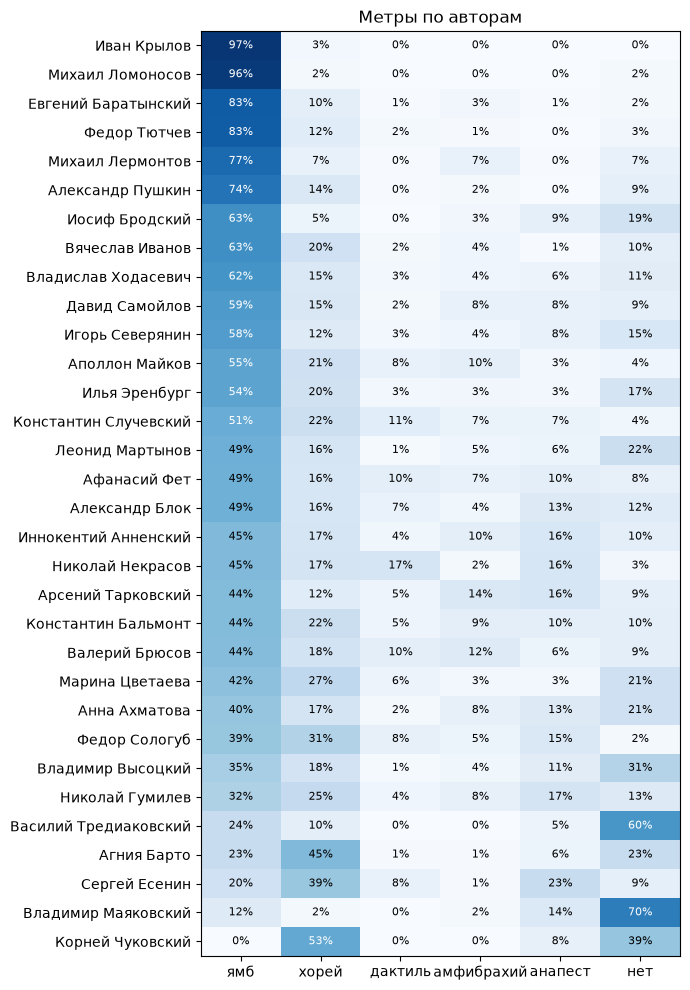

In [10]:
selected = [
    *verse["author"].value_counts().head(24).index,
    "Михаил Ломоносов",
    "Василий Тредиаковский",
    "Иван Крылов",
    "Николай Некрасов",
    "Владимир Маяковский",
    "Агния Барто",
    "Корней Чуковский",
    "Иосиф Бродский",
]
selected = list(dict.fromkeys(selected))
by_author = (
    pd.crosstab(verse["author"], verse["meter"], normalize="index")
    .loc[selected, METERS]
    .sort_values("ямб", ascending=False)
)
fig, ax = plt.subplots(figsize=(7, 10))
image = ax.imshow(by_author.to_numpy(), cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(METERS)), METERS)
ax.set_yticks(range(len(by_author)), by_author.index)
for row in range(len(by_author)):
    for column in range(len(METERS)):
        value = by_author.iloc[row, column]
        ax.text(
            column,
            row,
            f"{value:.0%}",
            ha="center",
            va="center",
            color="white" if value > 0.5 else "black",
            fontsize=8,
        )
ax.set_title("Метры по авторам")
plt.tight_layout()

## Рифма и окончания

В корпусе почти нет пустых строк между строфами, поэтому схема рифмовки целого стихотворения делится на четверостишия: буквы, у которых внутри четверостишия нет пары, заменяются дефисом. Перекрёстная рифмовка `ABAB` - треть всех четверостиший и половина в 1880-1909 годах; парная `AABB` заметна только в XVIII веке; `-A-A` - рифмуются лишь чётные строки, как в песне и народном стихе.

Доля четверостиший без единой найденной рифмы падает с 21% в XVIII веке (силлабика, белый стих, свободная строфика од) до 11% на рубеже веков и снова растёт до 25-30% после 1910 года. Это и белый стих с верлибром, и предел самого детектора: он требует совпадения группы согласных после ударной гласной, а неточная рифма XX века (*ветер - вечер*, усечённые и составные рифмы Маяковского) ему не видна.

In [11]:
from collections import Counter


def quatrains(scheme: str) -> list[str]:
    """Схема по четверостишиям: буквы без пары внутри четверостишия заменяются дефисом"""
    result = []
    for start in range(0, len(scheme) - len(scheme) % 4, 4):
        chunk = scheme[start : start + 4]
        counts = Counter(chunk)
        letters: dict[str, str] = {}
        normalized = []
        for letter in chunk:
            if letter == "-" or counts[letter] < 2:
                normalized.append("-")
            else:
                normalized.append(letters.setdefault(letter, chr(ord("A") + len(letters))))
        result.append("".join(normalized))
    return result


SCHEMES = ["ABAB", "ABBA", "AABB", "-A-A", "A-A-", "----"]
schemes_by_era = {}
for era, rows in dated.groupby("era", observed=True):
    counts = Counter(
        quatrain
        for schemes in rows["schemes"]
        for scheme in schemes
        for quatrain in quatrains(scheme)
    )
    total = sum(counts.values())
    schemes_by_era[era] = {scheme: counts[scheme] / total for scheme in SCHEMES}
(pd.DataFrame(schemes_by_era).T * 100).round(1)

,ABAB,ABBA,AABB,-A-A,A-A-,----
XVIII век,21.7,6.1,11.5,6.5,4.6,20.8
1800-1839,28.9,8.2,7.7,11.6,6.4,16.2
1840-1879,38.9,5.1,8.1,13.9,4.8,13.3
1880-1909,49.6,7.2,3.4,12.5,3.9,11.0
1910-1929,34.4,3.0,2.9,11.8,6.5,29.9
1930-1959,36.4,1.6,4.2,14.3,8.1,23.5
1960-1996,28.0,2.8,3.1,14.6,8.0,24.7


Окончания строк: в XVIII веке женских окончаний больше, чем мужских, с XIX века они делятся почти поровну (чередование в перекрёстной рифмовке), а дактилические окончания растут от 1-2% до 7% - их ввёл в широкий оборот Некрасов, а поэты XX века закрепили. Доля пиррихиев (иктов без ударения) держится около 20% во все эпохи.

,p_masculine,p_feminine,p_dactylic,p_pyrrhics
era,,,,
XVIII век,43.2,55.1,1.5,20.3
1800-1839,50.3,46.9,2.7,20.6
1840-1879,46.6,48.0,5.2,17.7
1880-1909,47.5,46.7,5.4,17.2
1910-1929,46.9,46.0,6.6,20.2
1930-1959,48.1,45.7,5.8,19.9
1960-1996,47.4,44.9,7.2,20.9


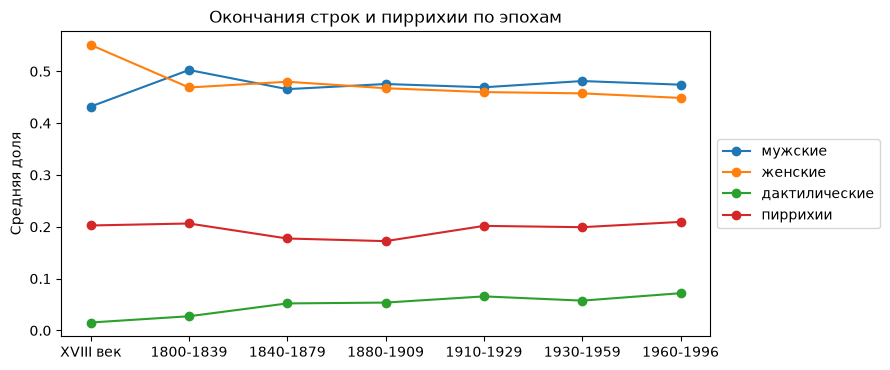

In [12]:
endings = dated.groupby("era", observed=True)[
    ["p_masculine", "p_feminine", "p_dactylic", "p_pyrrhics"]
].mean()
ax = endings.plot(marker="o", figsize=(9, 3.8))
ax.set_xlabel("")
ax.set_ylabel("Средняя доля")
ax.set_title("Окончания строк и пиррихии по эпохам")
ax.legend(
    ["мужские", "женские", "дактилические", "пиррихии"], loc="center left", bbox_to_anchor=(1, 0.5)
)
plt.tight_layout()
(endings * 100).round(1)

Стихотворения, где рифмуется меньше четверти строк, - белый стих и верлибр. Список авторов узнаваем: Рерих и Маяковский (свободный и акцентный стих), Кольцов (подражания народной песне без рифмы), Дельвиг с идиллиями в гекзаметре, Тургенев.

In [13]:
unrhymed = verse[(verse["p_rhymed"] < 0.25) & (verse["n_lines"] >= 8)]
print(len(unrhymed), "стихотворений")
unrhymed["author"].value_counts().head(8).to_frame("стихотворений").T

792 стихотворений


author,Николай Рерих,Владимир Маяковский,Алексей Кольцов,Иван Тургенев,Антон Дельвиг,Аполлон Майков,Роберт Рождественский,Михаил Кузмин
стихотворений,54,38,35,29,23,22,22,21


## Ударные гласные и звуковая инструментовка

Ударные гласные - материал ассонанса: в среднем по корпусу ударные а, о и е дают по 21-23%, и - 13%, у - 8%. Стихотворения, где одна ударная гласная занимает больше половины позиций, - хрестоматийная звукопись: «Ночной зефир струит эфир. Шумит, бежит Гвадалквивир» Пушкина на *и*, «Русский бог» Вяземского на *о* («бог метелей, бог ухабов...»), «Боль» Гиппиус на *у*.

In [14]:
vowel_share = pd.DataFrame(verse["vowels"].tolist()).fillna(0)
share = (vowel_share.sum() / vowel_share.sum().sum()).sort_values(ascending=False)
print("Ударные гласные в корпусе:", {vowel: round(value, 3) for vowel, value in share.items()})

dominant = []
for author, title, vowels in verse[["author", "title", "vowels"]].itertuples(index=False):
    total = sum(vowels.values())
    if total >= 40:
        vowel, count = max(vowels.items(), key=lambda item: item[1])
        dominant.append(
            {
                "автор": author,
                "название": title,
                "гласная": vowel,
                "доля": count / total,
                "ударений": total,
            }
        )
dominant = pd.DataFrame(dominant)
pd.concat([dominant[dominant["гласная"] == vowel].nlargest(2, "доля") for vowel in "иоуы"]).round(
    2
)

Ударные гласные в корпусе: {'а': 0.229, 'е': 0.217, 'о': 0.208, 'и': 0.133, 'у': 0.082, 'я': 0.057, 'ы': 0.05, 'ю': 0.012, 'э': 0.009, 'ё': 0.002}


,автор,название,гласная,доля,ударений
4049,Александр Пушкин,Ночной зефир струит эфир...,и,0.52,46
10871,Александр Пушкин,Ночной зефир...,и,0.52,46
1679,Петр Вяземский,Русский бог,о,0.56,124
3164,Борис Слуцкий,Молчаливый вой,о,0.53,43
3407,Зинаида Гиппиус,Боль,у,0.41,69
9403,Владимир Высоцкий,Вторая песенка Алисы,у,0.37,41
2471,Даниил Хармс,Миллион,ы,0.34,79
11367,Федор Сологуб,"Хнык, хнык, хнык!..",ы,0.31,96


У «Ночного зефира» ударное *и* - каждая вторая ударная гласная, и метр у стихотворения не определён: рефрен написан ямбом, а строфы между рефренами - хореем, так что ни один из пяти метров не укладывается в текст целиком.

In [15]:
zephyr = corpus.loc[corpus["title"].str.startswith("Ночной зефир"), "text"].iloc[0]
zephyr_stats = VerseStats(zephyr, stress_dict)
print(zephyr_stats.accentuate())
print()
print("Метр:", zephyr_stats.meter, " Ударные гласные:", zephyr_stats.c_stressed_vowels)

Ночно́й зефи́р
Струи́т эфи́р.
Шуми́т,
Бежи́т
Гвадалквиви́р.
Во́т взошла́ луна́ злата́я,
Ти́ше... чу́... гита́ры зво́н...
Во́т испа́нка молода́я
Оперлася на балко́н.
Ночно́й зефи́р
Струи́т эфи́р.
Шуми́т,
Бежи́т
Гвадалквиви́р.
Ски́нь манти́лью, а́нгел ми́лый,
И яви́сь ка́к я́ркий де́нь!
Скво́зь чугу́нные перилы
Но́жку ди́вную проде́нь!
Ночно́й зефи́р
Струи́т эфи́р.
Шуми́т,
Бежи́т
Гвадалквиви́р.

Метр: None  Ударные гласные: {'и': 24, 'о': 9, 'а': 8, 'у': 2, 'е': 2, 'я': 1}


`PhonStats` считает звуковой облик текста по буквам без ударений: доли классов звуков, «жёсткость» (глухие шумные к гласным и сонорным), индексы аллитерации и ассонанса - отношение числа окон из трёх соседних слов с повтором согласной (гласной) к ожидаемому при независимом распределении букв самого текста. Индекс измеряет локальную сгущённость повторов, а не общее преобладание звука: у «Камышей» Бальмонта, где *ш* и *с* повторяются почти в каждом слове, ожидание тоже высокое, и индекс аллитерации остаётся около единицы. Средний индекс по корпусу даже чуть ниже, чем в прозе (0.94 против 1.00 на текстах `TextsByGrade`) - строчная организация стиха рассыпает повторы по разным окнам. Зато верх списка по индексу - заумь Хлебникова и Кручёных и звукопись Асеева, где повторы сгущены в соседних словах.

In [16]:
from ruts import PhonStats
from ruts.datasets import TextsByGrade

phon = pd.DataFrame(PhonStats(text).get_stats() for text in corpus["text"])
phon = pd.concat([corpus[["author", "title", "n_words"]], phon], axis=1)
prose = pd.DataFrame(PhonStats(text).get_stats() for text in TextsByGrade().get_texts())
FEATURES = ["p_vowels", "p_sonorants", "hardness", "p_open_syllables", "alliteration", "assonance"]
pd.DataFrame(
    {"поэзия": phon[FEATURES].mean(), "проза (TextsByGrade)": prose[FEATURES].mean()}
).round(3).T

,p_vowels,p_sonorants,hardness,p_open_syllables,alliteration,assonance
поэзия,0.417,0.213,0.355,0.745,0.942,0.976
проза (TextsByGrade),0.430,0.205,0.356,0.787,0.998,1.011


In [17]:
phon[phon["n_words"] >= 60].nlargest(8, "alliteration")[
    ["author", "title", "alliteration", "assonance"]
].round(2)

,author,title,alliteration,assonance
13967,Велимир Хлебников,Перевертень,1.62,1.18
935,Алексей Крученых,Зима,1.42,1.15
12461,Николай Асеев,Работа,1.32,1.24
1421,Мирра Лохвицкая,Я хочу быть любимой тобой...,1.28,0.91
1005,Лев Мей,Сумерки,1.26,0.93
8822,Николай Асеев,Собачий поезд,1.25,1.15
3584,Владимир Высоцкий,"Бросьте скуку, как корку арбузную!..",1.23,1.03
15866,Давид Самойлов,Итог,1.23,1.02


По авторам различия невелики, но осмысленны: самый высокий средний индекс аллитерации у Маяковского, Пастернака и Асеева, самый низкий - у Батюшкова, чей стих считали образцом благозвучия, и у Лермонтова. «Жёсткость» ниже всего у Языкова, Баратынского и Мережковского, выше всего у Кушнера, Коржавина и Крылова.

In [18]:
by_author = phon.groupby("author")[["alliteration", "assonance", "hardness", "p_vowels"]].agg(
    ["mean", "count"]
)
by_author = by_author[by_author[("alliteration", "count")] >= 60]
summary = pd.DataFrame(
    {
        "аллитерация": by_author[("alliteration", "mean")],
        "ассонанс": by_author[("assonance", "mean")],
        "жёсткость": by_author[("hardness", "mean")],
        "доля гласных": by_author[("p_vowels", "mean")],
    }
)
pd.concat([summary.nlargest(5, "аллитерация"), summary.nsmallest(5, "аллитерация")]).round(3)

,аллитерация,ассонанс,жёсткость,доля гласных
author,,,,
Владимир Маяковский,1.029,0.996,0.363,0.420
Борис Пастернак,0.997,0.996,0.393,0.411
Николай Асеев,0.996,0.994,0.367,0.414
Михаил Кузмин,0.989,0.998,0.363,0.416
Иосиф Уткин,0.986,0.986,0.368,0.420
Константин Батюшков,0.875,0.938,0.357,0.414
Самуил Маршак,0.889,0.948,0.373,0.416
Михаил Лермонтов,0.892,0.950,0.343,0.412
Юлия Друнина,0.899,0.967,0.365,0.419


In [19]:
pd.concat([summary.nlargest(3, "жёсткость"), summary.nsmallest(3, "жёсткость")]).round(3)

,аллитерация,ассонанс,жёсткость,доля гласных
author,,,,
Александр Кушнер,0.956,0.985,0.405,0.412
Наум Коржавин,0.941,0.957,0.400,0.413
Иван Крылов,0.933,0.973,0.398,0.416
Николай Языков,0.934,0.978,0.316,0.424
Евгений Баратынский,0.928,0.965,0.319,0.415
Дмитрий Мережковский,0.906,0.986,0.326,0.415


Слой `alliteration` подсветки отмечает повторы согласной в соседних словах, маловероятные при частотах букв русского языка. На «Челне томленья» Бальмонта он находит то, ради чего стихотворение написано.

In [20]:
from ruts.visualizers import highlight

balmont = corpus.loc[corpus["title"].str.startswith("Челн томленья"), "text"].iloc[0]
highlight(balmont, layers="alliteration")

HighlightedText(counts={'alliteration': 4})

## Проверка на RIFMA

Насколько верны автоматические ударения и рифмы? Набор [RIFMA](https://github.com/Koziev/Rifma) (MIT) - 5 121 строфа с ручной расстановкой ударений и схемами рифмовки. Ударения сверяются пословно, рифмы - по парам строк в окне четырёх строк той же строфы.

In [21]:
import json
import re
from pathlib import Path

from ruts.utils import download_file

RIFMA_COMMIT = "fd65d75ed12b92a49c6bdf1437de037ebaa18560"
RIFMA_URL = f"https://github.com/Koziev/Rifma/raw/{RIFMA_COMMIT}/rifma_dataset.json"
rifma_path = Path(pc.data_dir) / "rifma_dataset.json"
download_file(RIFMA_URL, filename=rifma_path.name, dirpath=rifma_path.parent)
rifma = json.loads(rifma_path.read_text(encoding="utf-8"))
VOWELS = set("аеёиоуыэюя")
WORD = re.compile(r"[а-яёА-ЯЁ\u0301\u0300]+(?:-[а-яёА-ЯЁ\u0301\u0300]+)*")


def gold_stresses(markup: str) -> list[list[tuple[str, int]]]:
    """Слова строк с номером ударного слога по разметке, -1 у безударных"""
    lines = []
    for line in markup.split("\n"):
        words = []
        for match in WORD.finditer(line):
            word = match.group()
            plain = word.replace("\u0301", "").replace("\u0300", "").lower()
            if not any(letter in VOWELS for letter in plain):
                continue
            if "\u0301" in word:
                before = word[: word.index("\u0301")].replace("\u0300", "").lower()
                stress = sum(letter in VOWELS for letter in before) - 1
            else:
                stress = -1
            words.append((plain, stress))
        if words:
            lines.append(words)
    return lines


totals = Counter()
pairs = Counter()
for item in rifma:
    vs = VerseStats(item["poem_text"], stress_dict)
    gold = gold_stresses(item["accentuation_markup"])
    if len(gold) == vs.n_lines:
        for line, gold_line in zip(vs._lines, gold, strict=True):
            words = [word for word in line.words if word.n_syllables]
            if [word.text for word in words] != [word for word, _ in gold_line]:
                continue
            for word, (_, stress) in zip(words, gold_line, strict=True):
                totals["слов"] += 1
                totals["верно"] += word.result == stress
    if item["rhyme_scheme"]:
        gold_schemes = item["rhyme_scheme"].split()
        if [len(scheme) for scheme in gold_schemes] == [
            len(scheme) for scheme in vs.rhyme_schemes
        ]:
            for gold_scheme, scheme in zip(gold_schemes, vs.rhyme_schemes, strict=True):
                for i in range(len(gold_scheme)):
                    for j in range(max(0, i - 4), i):
                        expected = gold_scheme[i] != "-" and gold_scheme[i] == gold_scheme[j]
                        found = scheme[i] != "-" and scheme[i] == scheme[j]
                        pairs[
                            "tp"
                            if expected and found
                            else "fp"
                            if found
                            else "fn"
                            if expected
                            else "tn"
                        ] += 1
precision = pairs["tp"] / (pairs["tp"] + pairs["fp"])
recall = pairs["tp"] / (pairs["tp"] + pairs["fn"])
print(f"Ударения: {totals['верно'] / totals['слов']:.1%} из {totals['слов']} слов")
print(f"Рифмы: точность {precision:.1%}, полнота {recall:.1%}")

Ударения: 96.7% из 89805 слов
Рифмы: точность 93.7%, полнота 90.1%


## Итоги

*   Автоматический разбор воспроизводит историю русского стиха по ручным подсчётам: господство ямба и александрийского шестистопника в XVIII веке, пик ямба в пушкинскую эпоху, выход трёхсложников на 20% с 1840-х, рост пятистопного ямба и текстов без силлабо-тонического метра в XX веке.
*   Профиль ударности четырёхстопного ямба совпадает со стиховедческим: рамочный у Ломоносова (первый икт сильнее второго), альтернирующий у Пушкина - 84, 91, 44 и 99% против 84, 90, 44 и 100% у Тарановского.
*   Метр «не подобран» - тоже результат: он выделяет силлабику Тредиаковского, акцентный стих Маяковского и дольники 1910-1920-х, а у Пушкина остаётся только за гекзаметрами и подражаниями народному стиху.
*   Онегинская строфа распознаётся целиком (`ABABCCDDEFFEGG`, 8 мужских и 6 женских окончаний); в корпусе перекрёстная рифмовка - треть четверостиший, парная почти исчезает после XVIII века, дактилические окончания растут от 1% до 7%. Неточная рифма XX века детектору не видна - доля четверостиший без найденной рифмы после 1910 года удваивается.
*   Ударные гласные находят хрестоматийную звукопись (*и* у Пушкина, *о* у Вяземского, *у* у Гиппиус), а индекс аллитерации измеряет сгущённость повторов, а не преобладание звука: он выделяет заумь и Асеева, но не «Камыши», где повторы равномерны.
*   На RIFMA ударения совпадают с ручной разметкой у 97% слов, рифмы находятся с точностью 94% и полнотой 90%.